In [41]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [83]:
boss_rand_df = pd.read_csv('./experiment-results/rand-results.csv')
boss_bixi_df = pd.read_csv('./experiment-results/bixi-results.csv')
competition_rand_df = pd.read_csv('./experiment-results/competition-rand-results.csv')
competition_bixi_df = pd.read_csv('./experiment-results/competition-bixi-results.csv')

rand_df = pd.merge(boss_rand_df, competition_rand_df, left_on='table-name', right_on='table-name')
bixi_df = pd.merge(boss_bixi_df, competition_bixi_df, left_on='table-name', right_on='table-name')

rand_tables = rand_df.iloc[:, 0].tolist()
rand_tasks = (rand_df.iloc[:, 1 : ] / (10 ** 6)).to_dict(orient='list')

bixi_tables = bixi_df.iloc[:, 0].tolist()
bixi_tasks = (bixi_df.iloc[:, 1 : ] / (10 ** 6)).to_dict(orient='list')

# print(rand_tables)
# print(rand_tasks)

# print()

# print(bixi_tables)
# print(bixi_tasks)

print(rand_df)
print()
print(bixi_df)

  table-name  data-in  round-trip  materialise-columns  materialise-matrix  \
0       _64b   323661      206580               298343              383365   
1       _1mb   245641      183084               749874             1563169   
2      _10mb   421392      375635              5738784            11474785   
3     _100mb   277872      171950             30717028            92198254   
4       _1gb   343971      227142            150382026           762281640   
5       _2gb   384806      238978            339213886          2715601378   

   matrix-vector-product  matrix-matrix-product  pandas-data_in  \
0                 353128                 305676         2276355   
1                1039239                1930252        18789492   
2                9290114                7658740       146854753   
3               71890333               60735913      1392689111   
4              437297305              412618275     18069297980   
5             1004508678             3396209959    

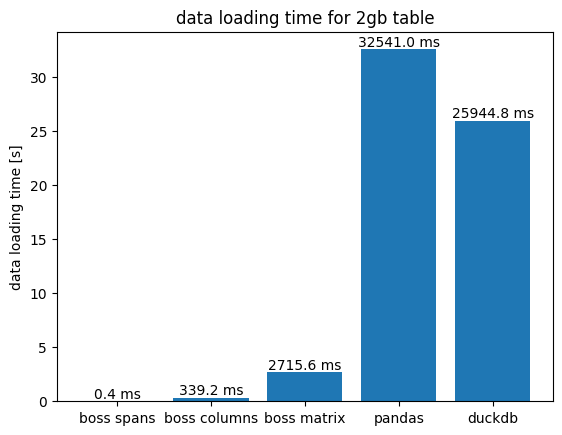

In [97]:
vendor_tasks = ['data-in', 'materialise-columns', 'materialise-matrix', 'pandas-data_in', 'duckdb-data_in']
vendors = ['boss spans', 'boss columns', 'boss matrix', 'pandas', 'duckdb']
times = []
for x in vendor_tasks:
    times.append(rand_df.loc[5, x] / (10 ** 9))

fig, ax = plt.subplots()
bar_container = ax.bar(vendors, times)
ax.set(ylabel='data loading time [s]', title='data loading time for 2gb table')
ax.bar_label(bar_container, fmt=lambda x: f'{x * (10 ** 3):.1f} ms')

plt.show()

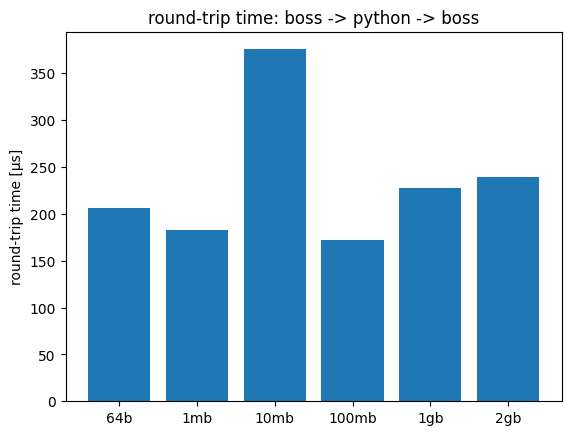

In [101]:
times = rand_df.loc[:, 'round-trip'] / (10 ** 3)
table_names = [x[ 1 : ] for x in rand_df.loc[:, 'table-name']]

fig, ax = plt.subplots()
bar_container = ax.bar(table_names, times)
ax.set(ylabel='round-trip time [µs]', title='round-trip time: boss -> python -> boss')

plt.show()

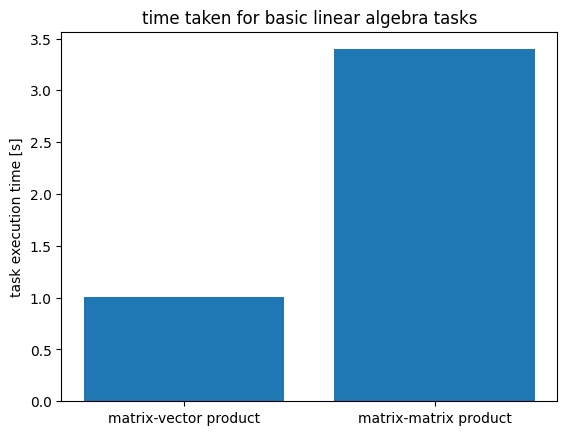

In [106]:
tasks = ['matrix-vector product', 'matrix-matrix product']
mvp = rand_df.loc[5, 'matrix-vector-product'] / (10 ** 9)
mmp = rand_df.loc[5, 'matrix-matrix-product'] / (10 ** 9)
times = [mvp, mmp]

fig, ax = plt.subplots()
bar_container = ax.bar(tasks, times)
ax.set(ylabel='task execution time [s]', title='time taken for basic linear algebra tasks')

plt.show()

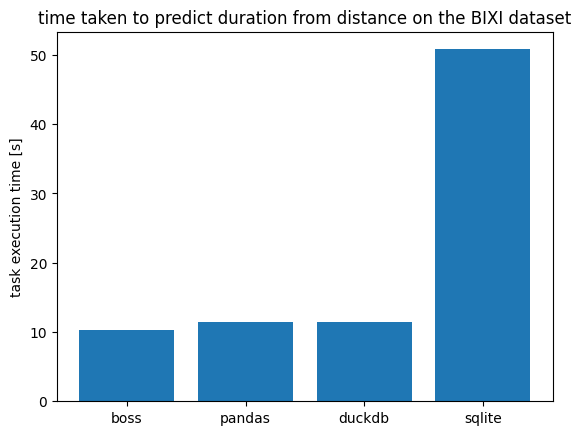

In [110]:
task = 'predict_duration_from_distance'
vendors = [
    '',
    'pandas-',
    'duckdb-',
    'sqlite-',
]
tasks = [f'{x}{task}' for x in vendors]
times = [bixi_df.loc[0, x] / (10 ** 9) for x in tasks]
task_names = ['boss', 'pandas', 'duckdb', 'sqlite']

fig, ax = plt.subplots()
bar_container = ax.bar(task_names, times)
ax.set(ylabel='task execution time [s]', title='BIXI total execution time')

plt.show()

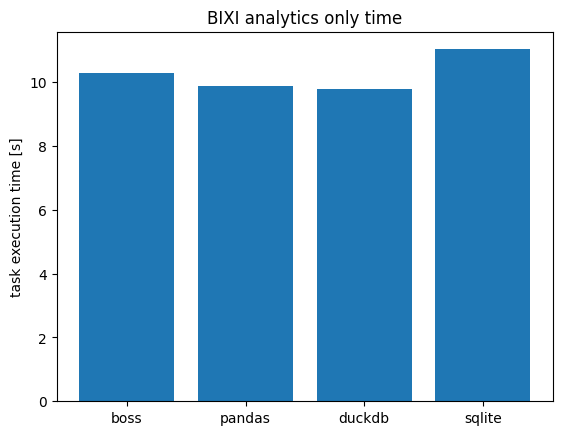

In [117]:
task = 'predict_duration_from_distance'
vendors = [
    '',
    'pandas-',
    'duckdb-',
    'sqlite-',
]
tasks = [f'{x}{task}' for x in vendors]
total_times = [bixi_df.loc[0, x] / (10 ** 9) for x in tasks]
loading_tasks = [
    'data-in',
    'pandas-data_in',
    'duckdb-data_in',
    'sqlite-data_in',
]

loading_times = [bixi_df.loc[0, x] / (10 ** 9) for x in loading_tasks]
analytics_times = []
for i in range(len(total_times)):
    analytics_times.append(total_times[i] - loading_times[i])
task_names = ['boss', 'pandas', 'duckdb', 'sqlite']

fig, ax = plt.subplots()
bar_container = ax.bar(task_names, analytics_times)
ax.set(ylabel='task execution time [s]', title='BIXI analytics only time')

plt.show()

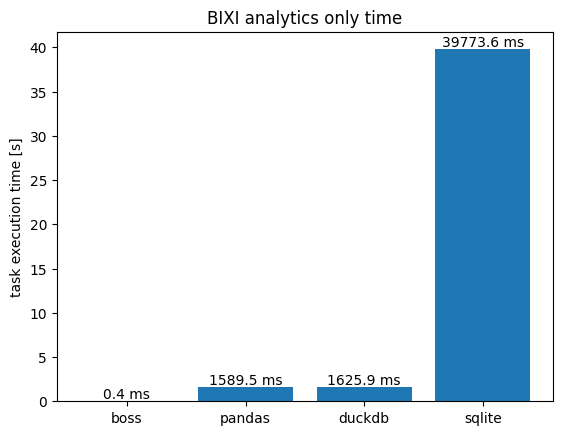

In [118]:
loading_tasks = [
    'data-in',
    'pandas-data_in',
    'duckdb-data_in',
    'sqlite-data_in',
]

loading_times = [bixi_df.loc[0, x] / (10 ** 9) for x in loading_tasks]
task_names = ['boss', 'pandas', 'duckdb', 'sqlite']

fig, ax = plt.subplots()
bar_container = ax.bar(task_names, loading_times)
ax.set(ylabel='task execution time [s]', title='BIXI analytics only time')
ax.bar_label(bar_container, fmt=lambda x: f'{x * (10 ** 3):.1f} ms')

plt.show()

In [69]:
# rand_tables = species = ("Adelie", "Chinstrap", "Gentoo")
# rand_tasks = penguin_means = {
#     'Bill Depth': (18.35, 18.43, 14.98),
#     'Bill Length': (38.79, 48.83, 47.50),
#     'Flipper Length': (189.95, 195.82, 217.19),
# }

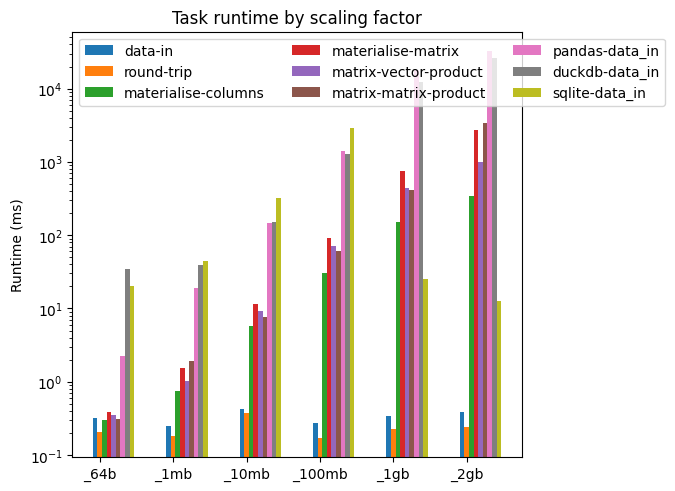

In [70]:
x = np.arange(len(rand_tables)) * 4
width = 0.25  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for attribute, measurement in rand_tasks.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    # ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Runtime (ms)')
ax.set_title('Task runtime by scaling factor')
ax.set_xticks(x + width, rand_tables)
ax.legend(loc='upper left', ncols=3)
# ax.set_ylim(0, 250)
plt.yscale('log')

plt.show()

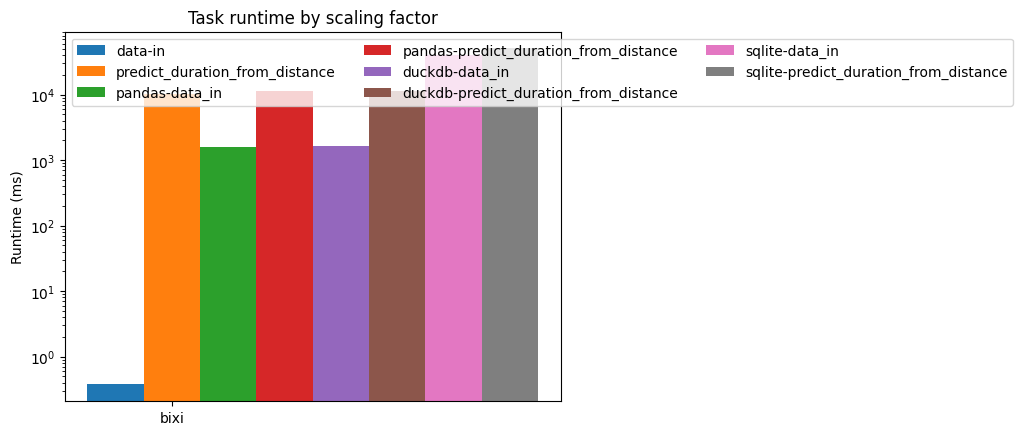

In [76]:
x = np.arange(len(bixi_tables)) * 4
width = 5.0  # the width of the bars
multiplier = 0

fig, ax = plt.subplots()

for attribute, measurement in bixi_tasks.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)
    # ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Runtime (ms)')
ax.set_title('Task runtime by scaling factor')
ax.set_xticks(x + width, bixi_tables)
ax.legend(loc='upper left', ncols=3)
# ax.set_ylim(0, 250)
plt.yscale('log')

plt.show()